In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, roc_auc_score, recall_score, precision_score, f1_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import files
df = files.upload()

Saving hubGene_exp (1).csv to hubGene_exp (1).csv


In [ ]:
# Load data
df = pd.read_csv("hubGene_exp (1).csv")
print(df.head())

   CCNB1  TOP2A  CENPA  label
0   4018  10856    419  Tumor
1    724   2403    125  Tumor
2   6670  15528    798  Tumor
3   2728  10046    501  Tumor
4    334    613     38  Tumor


In [ ]:
df['label'].value_counts()

,count
label,
Tumor,541
Normal,59


In [ ]:
# column names
print(df.columns)
print(df['label'].value_counts())

Index(['CCNB1', 'TOP2A', 'CENPA', 'label'], dtype='object')
label
Tumor     541
Normal     59
Name: count, dtype: int64


In [ ]:
# Map target variable to binary values
df['label'] = df['label'].map({'Tumor': 1, 'Normal': 0})

# Define features
feature_cols = ['CCNB1', 'TOP2A', 'CENPA']

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=16)

In [ ]:
# Normalize features using z-score normalization
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

In [ ]:
df.head()

,CCNB1,TOP2A,CENPA,label
0,1.015776,0.705213,0.246831,1
1,-0.623471,-0.522064,-0.448678,1
2,2.335534,1.383533,1.143423,1
3,0.373812,0.587611,0.440816,1
4,-0.817553,-0.781951,-0.654492,1


In [ ]:
df['label'].value_counts()

,count
label,
1,541
0,59


In [ ]:
# Initialize plot
plt.figure(figsize=(8, 6))

# Dictionary to store metrics for each fold and feature
auc_fold_dict = {}
recall_fold_dict = {}
precision_fold_dict = {}
f1_fold_dict = {}
mcc_fold_dict = {}
specificity_fold_dict = {}  # New dictionary for specificity

# Function to calculate specificity
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Iterate over each feature
for feature in feature_cols:
    # Initialize lists to store true labels and predicted probabilities
    true_labels = []
    pred_probs = []
    pred_labels = []

    # Initialize lists to store metrics for each fold
    auc_fold_dict[feature] = []
    recall_fold_dict[feature] = []
    precision_fold_dict[feature] = []
    f1_fold_dict[feature] = []
    mcc_fold_dict[feature] = []
    specificity_fold_dict[feature] = []  # New list for specificity

    # Iterate over each fold
    for fold_idx, (train_index, test_index) in enumerate(skf.split(df[feature], df['label']), 1):
        # Split data into train and test sets
        X_train, X_test = df.iloc[train_index][[feature]], df.iloc[test_index][[feature]]
        y_train, y_test = df.iloc[train_index]['label'], df.iloc[test_index]['label']

        # Train logistic regression model
        model = LogisticRegression(random_state=10)
        model.fit(X_train, y_train)

        # Predict probabilities on test set
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred_label = model.predict(X_test)

        # Append true labels and predicted probabilities
        true_labels.extend(y_test)
        pred_probs.extend(y_pred_proba)
        pred_labels.extend(y_pred_label)

        # Compute metrics for current fold
        auc = roc_auc_score(y_test, y_pred_proba)
        recall = recall_score(y_test, y_pred_label)
        precision = precision_score(y_test, y_pred_label)
        f1 = f1_score(y_test, y_pred_label)
        mcc = matthews_corrcoef(y_test, y_pred_label)
        specificity = specificity_score(y_test, y_pred_label)  # Calculate specificity

        # Append metrics to respective lists
        auc_fold_dict[feature].append(auc)
        recall_fold_dict[feature].append(recall)
        precision_fold_dict[feature].append(precision)
        f1_fold_dict[feature].append(f1)
        mcc_fold_dict[feature].append(mcc)
        specificity_fold_dict[feature].append(specificity)  # Append specificity

    # Compute overall ROC curve and AUC
    fpr, tpr, _ = roc_curve(true_labels, pred_probs)
    mean_auc = np.mean(auc_fold_dict[feature])

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{feature} (AUC={round(mean_auc, 4)})")

# Add random line and labels
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.legend()
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC curve')
plt.grid(True)

# Save plot to PDF and PNG
plt.savefig('plt_combat_z.pdf', format='pdf', bbox_inches='tight')
plt.savefig('plt_combat_Z.png', format='png', bbox_inches='tight')

# Save performance metrics to CSV file
performance_metrics = pd.DataFrame({
    ####################################
    'ROC': ['combat_Z'] * len(feature_cols),
    'Feature': feature_cols,
    'AUC': [round(np.mean(auc_fold_dict[feature]), 4) for feature in feature_cols],
    'Recall': [round(np.mean(recall_fold_dict[feature]), 4) for feature in feature_cols],
    'Precision': [round(np.mean(precision_fold_dict[feature]), 4) for feature in feature_cols],
    'F1 Score': [round(np.mean(f1_fold_dict[feature]), 4) for feature in feature_cols],
    'MCC': [round(np.mean(mcc_fold_dict[feature]), 4) for feature in feature_cols],
    'Specificity': [round(np.mean(specificity_fold_dict[feature]), 4) for feature in feature_cols],  # Add specificity
})

performance_metrics.to_csv('performance1.csv', index=False)

NameError: name 'plt' is not defined

In [ ]:
performance_metrics

,ROC,Feature,AUC,Recall,Precision,F1 Score,MCC,Specificity
0,combat_Z,CCNB1,0.9675,1.0,0.9017,0.9483,0.0,0.0
1,combat_Z,KIF11,0.9730,1.0,0.9017,0.9483,0.0,0.0
2,combat_Z,CCNA2,0.9631,1.0,0.9017,0.9483,0.0,0.0
3,combat_Z,BUB1,0.9538,1.0,0.9017,0.9483,0.0,0.0


In [ ]:
X_train.shape, X_test.shape, y_train.shape

((540, 1), (60, 1), (540,))

In [ ]:
print(f'train: {y_train.value_counts()}')

print(f'test: {y_test.value_counts()}')

train: label
1    487
0     53
Name: count, dtype: int64
test: label
1    54
0     6
Name: count, dtype: int64


In [ ]:
df['label'].value_counts()

,count
label,
Tumor,541
Normal,59


#Synthetic Minority Over-Sampling Technique (SMOTE)
* To balance the class

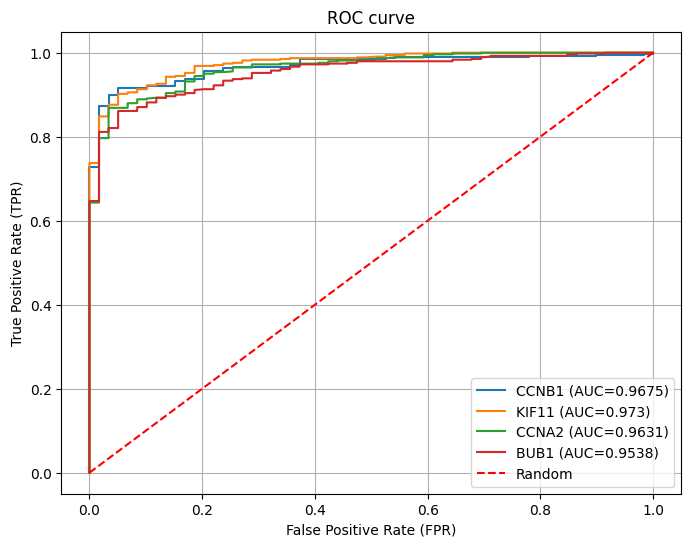

In [ ]:
from imblearn.over_sampling import SMOTE

# Initialize plot
plt.figure(figsize=(8, 6))

# Dictionary to store metrics for each fold and feature
auc_fold_dict = {}
recall_fold_dict = {}
precision_fold_dict = {}
f1_fold_dict = {}
mcc_fold_dict = {}
specificity_fold_dict = {}  # New dictionary for specificity

# Function to calculate specificity
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Iterate over each feature
for feature in feature_cols:
    # Initialize lists to store true labels and predicted probabilities
    true_labels = []
    pred_probs = []
    pred_labels = []

    # Initialize lists to store metrics for each fold
    auc_fold_dict[feature] = []
    recall_fold_dict[feature] = []
    precision_fold_dict[feature] = []
    f1_fold_dict[feature] = []
    mcc_fold_dict[feature] = []
    specificity_fold_dict[feature] = []  # New list for specificity

    # Iterate over each fold
    for fold_idx, (train_index, test_index) in enumerate(skf.split(df[feature], df['label']), 1):
        # Split data into train and test sets
        X_train, X_test = df.iloc[train_index][[feature]], df.iloc[test_index][[feature]]
        y_train, y_test = df.iloc[train_index]['label'], df.iloc[test_index]['label']

        # Apply SMOTE on the training data to address class imbalance
        sm = SMOTE(random_state=42)
        X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

        # Train logistic regression model on the resampled data
        model = LogisticRegression(random_state=10)
        model.fit(X_train_res, y_train_res)

        # Predict probabilities and labels on test set
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred_label = model.predict(X_test)

        # Append true labels and predicted probabilities
        true_labels.extend(y_test)
        pred_probs.extend(y_pred_proba)
        pred_labels.extend(y_pred_label)

        # Compute metrics for current fold
        auc = roc_auc_score(y_test, y_pred_proba)
        recall = recall_score(y_test, y_pred_label)
        precision = precision_score(y_test, y_pred_label)
        f1 = f1_score(y_test, y_pred_label)
        mcc = matthews_corrcoef(y_test, y_pred_label)
        specificity = specificity_score(y_test, y_pred_label)  # Calculate specificity

        # Append metrics to respective lists
        auc_fold_dict[feature].append(auc)
        recall_fold_dict[feature].append(recall)
        precision_fold_dict[feature].append(precision)
        f1_fold_dict[feature].append(f1)
        mcc_fold_dict[feature].append(mcc)
        specificity_fold_dict[feature].append(specificity)

    # Compute overall ROC curve and AUC
    fpr, tpr, _ = roc_curve(true_labels, pred_probs)
    mean_auc = np.mean(auc_fold_dict[feature])

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{feature} (AUC={round(mean_auc, 4)})")

# Add random line and labels
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.legend()
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC curve')
plt.grid(True)

# Save plot to PDF and PNG
plt.savefig('plt_combat_z.pdf', format='pdf', bbox_inches='tight')
plt.savefig('plt_combat_Z.png', format='png', bbox_inches='tight')

# Save performance metrics to CSV file
performance_metrics = pd.DataFrame({
    'ROC': ['combat_Z'] * len(feature_cols),
    'Feature': feature_cols,
    'AUC': [round(np.mean(auc_fold_dict[feature]), 4) for feature in feature_cols],
    'Recall': [round(np.mean(recall_fold_dict[feature]), 4) for feature in feature_cols],
    'Precision': [round(np.mean(precision_fold_dict[feature]), 4) for feature in feature_cols],
    'F1 Score': [round(np.mean(f1_fold_dict[feature]), 4) for feature in feature_cols],
    'MCC': [round(np.mean(mcc_fold_dict[feature]), 4) for feature in feature_cols],
    'Specificity': [round(np.mean(specificity_fold_dict[feature]), 4) for feature in feature_cols],
})

performance_metrics.to_csv('performance.csv', index=False)

In [ ]:
performance_metrics

,ROC,Feature,AUC,Recall,Precision,F1 Score,MCC,Specificity
0,combat_Z,CCNB1,0.9675,0.8446,0.9979,0.9137,0.5920,0.9833
1,combat_Z,KIF11,0.9730,0.8372,0.9979,0.9088,0.5854,0.9833
2,combat_Z,CCNA2,0.9631,0.8021,0.9954,0.8863,0.5275,0.9667
3,combat_Z,BUB1,0.9538,0.7909,0.9977,0.8802,0.5235,0.9833


In [ ]:
y_train_res.value_counts()

(label
 1    487
 0    487
 Name: count, dtype: int64,)

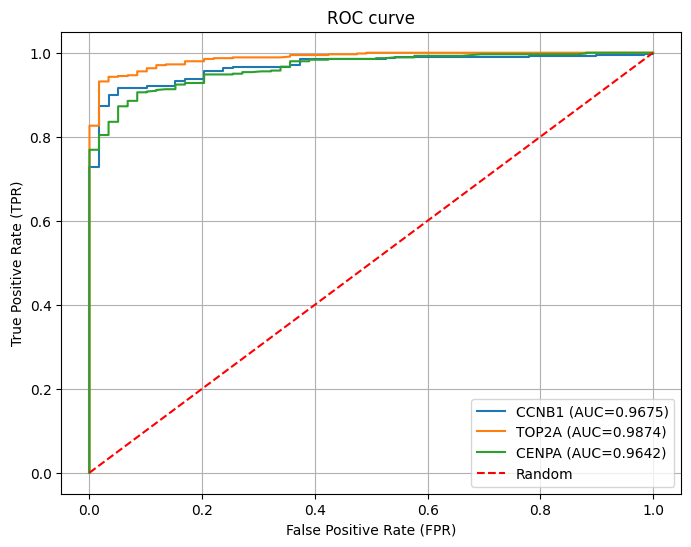

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, matthews_corrcoef, roc_curve, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Initialize plot
plt.figure(figsize=(8, 6))

# Dictionary to store metrics for each fold and feature
auc_fold_dict = {}
recall_fold_dict = {}
precision_fold_dict = {}
f1_fold_dict = {}
mcc_fold_dict = {}
specificity_fold_dict = {}  # New dictionary for specificity
accuracy_fold_dict = {}     # New dictionary for accuracy

# Function to calculate specificity
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Iterate over each feature
for feature in feature_cols:
    # Initialize lists to store true labels and predicted probabilities
    true_labels = []
    pred_probs = []
    pred_labels = []

    # Initialize lists to store metrics for each fold
    auc_fold_dict[feature] = []
    recall_fold_dict[feature] = []
    precision_fold_dict[feature] = []
    f1_fold_dict[feature] = []
    mcc_fold_dict[feature] = []
    specificity_fold_dict[feature] = []  # New list for specificity
    accuracy_fold_dict[feature] = []       # New list for accuracy

    # Iterate over each fold
    for fold_idx, (train_index, test_index) in enumerate(skf.split(df[feature], df['label']), 1):
        # Split data into train and test sets
        X_train, X_test = df.iloc[train_index][[feature]], df.iloc[test_index][[feature]]
        y_train, y_test = df.iloc[train_index]['label'], df.iloc[test_index]['label']

        # Apply SMOTE on the training data to address class imbalance
        sm = SMOTE(random_state=42)
        X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

        # Train logistic regression model on the resampled data
        model = LogisticRegression(random_state=10)
        model.fit(X_train_res, y_train_res)

        # Predict probabilities and labels on test set
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred_label = model.predict(X_test)

        # Append true labels and predicted probabilities
        true_labels.extend(y_test)
        pred_probs.extend(y_pred_proba)
        pred_labels.extend(y_pred_label)

        # Compute metrics for current fold
        auc = roc_auc_score(y_test, y_pred_proba)
        recall = recall_score(y_test, y_pred_label)
        precision = precision_score(y_test, y_pred_label)
        f1 = f1_score(y_test, y_pred_label)
        mcc = matthews_corrcoef(y_test, y_pred_label)
        specificity = specificity_score(y_test, y_pred_label)  # Calculate specificity
        accuracy = accuracy_score(y_test, y_pred_label)         # Calculate accuracy

        # Append metrics to respective lists
        auc_fold_dict[feature].append(auc)
        recall_fold_dict[feature].append(recall)
        precision_fold_dict[feature].append(precision)
        f1_fold_dict[feature].append(f1)
        mcc_fold_dict[feature].append(mcc)
        specificity_fold_dict[feature].append(specificity)
        accuracy_fold_dict[feature].append(accuracy)

    # Compute overall ROC curve and AUC
    fpr, tpr, _ = roc_curve(true_labels, pred_probs)
    mean_auc = np.mean(auc_fold_dict[feature])

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{feature} (AUC={round(mean_auc, 4)})")

# Add random line and labels
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.legend()
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC curve')
plt.grid(True)

# Save plot to PDF and PNG
plt.savefig('plt_combat_z.pdf', format='pdf', bbox_inches='tight')
plt.savefig('plt_combat_Z.png', format='png', bbox_inches='tight')

# Save performance metrics to CSV file
performance_metrics = pd.DataFrame({
    'ROC': ['combat_Z'] * len(feature_cols),
    'Feature': feature_cols,
    'AUC': [round(np.mean(auc_fold_dict[feature]), 4) for feature in feature_cols],
    'Recall': [round(np.mean(recall_fold_dict[feature]), 4) for feature in feature_cols],
    'Precision': [round(np.mean(precision_fold_dict[feature]), 4) for feature in feature_cols],
    'F1 Score': [round(np.mean(f1_fold_dict[feature]), 4) for feature in feature_cols],
    'MCC': [round(np.mean(mcc_fold_dict[feature]), 4) for feature in feature_cols],
    'Specificity': [round(np.mean(specificity_fold_dict[feature]), 4) for feature in feature_cols],
    'Accuracy': [round(np.mean(accuracy_fold_dict[feature]), 4) for feature in feature_cols]  # Added accuracy
})

performance_metrics.to_csv('performance.csv', index=False)

In [ ]:
performance_metrics

,ROC,Feature,AUC,Recall,Precision,F1 Score,MCC,Specificity,Accuracy
0,combat_Z,CCNB1,0.9675,0.8446,0.9979,0.9137,0.5920,0.9833,0.8583
1,combat_Z,TOP2A,0.9874,0.8335,0.9979,0.9067,0.5772,0.9833,0.8483
2,combat_Z,CENPA,0.9642,0.7799,0.9977,0.8739,0.5064,0.9833,0.8000


# With Class and Gender (Attribute) Balance

In [ ]:
from google.colab import files
df = files.upload()

Saving 9_HubGene_classBalance.csv to 9_HubGene_classBalance.csv


In [ ]:
# Load data
df = pd.read_csv("9_HubGene_classBalance.csv")
print(df.head())

        CCNB1        TOP2A      CENPA   class  gender
0  652.215110  1131.054324  70.192584  Normal  female
1  308.748245   490.989368  32.494684  Normal  female
2  302.577058   507.970447  30.573774  Normal  female
3  269.000000   224.000000  19.000000  Normal  female
4  343.832507   503.619702  38.809851  Normal  female


In [ ]:
# column names
print(df.columns)
print(df['class'].value_counts())
print(df['gender'].value_counts())

Index(['CCNB1', 'TOP2A', 'CENPA', 'class', 'gender'], dtype='object')
class
Normal    450
Tumor     450
Name: count, dtype: int64
gender
female    450
male      450
Name: count, dtype: int64


In [ ]:
# Map target variable to binary values
df['class'] = df['class'].map({'Tumor': 1, 'Normal': 0})

# Define features
feature_cols = ['CCNB1', 'TOP2A', 'CENPA']

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=16)

# Normalize features using z-score normalization
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

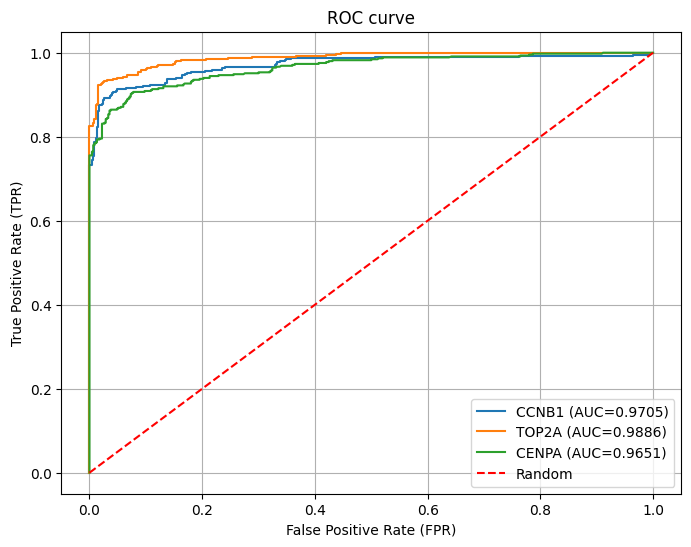

In [ ]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, matthews_corrcoef, roc_curve, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Initialize plot
plt.figure(figsize=(8, 6))

# Dictionary to store metrics for each fold and feature
auc_fold_dict = {}
recall_fold_dict = {}
precision_fold_dict = {}
f1_fold_dict = {}
mcc_fold_dict = {}
specificity_fold_dict = {}  # New dictionary for specificity
accuracy_fold_dict = {}

# Function to calculate specificity
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

# Iterate over each feature
for feature in feature_cols:
    # Initialize lists to store true labels and predicted probabilities
    true_labels = []
    pred_probs = []
    pred_labels = []

    # Initialize lists to store metrics for each fold
    auc_fold_dict[feature] = []
    recall_fold_dict[feature] = []
    precision_fold_dict[feature] = []
    f1_fold_dict[feature] = []
    mcc_fold_dict[feature] = []
    specificity_fold_dict[feature] = []  # New list for specificity
    accuracy_fold_dict[feature] = []

    # Iterate over each fold
    for fold_idx, (train_index, test_index) in enumerate(skf.split(df[feature], df['class']), 1):
        # Split data into train and test sets
        X_train, X_test = df.iloc[train_index][[feature]], df.iloc[test_index][[feature]]
        y_train, y_test = df.iloc[train_index]['class'], df.iloc[test_index]['class']

        # Train logistic regression model
        model = LogisticRegression(random_state=10)
        model.fit(X_train, y_train)

        # Predict probabilities on test set
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred_label = model.predict(X_test)

        # Append true labels and predicted probabilities
        true_labels.extend(y_test)
        pred_probs.extend(y_pred_proba)
        pred_labels.extend(y_pred_label)

        # Compute metrics for current fold
        auc = roc_auc_score(y_test, y_pred_proba)
        recall = recall_score(y_test, y_pred_label)
        precision = precision_score(y_test, y_pred_label)
        f1 = f1_score(y_test, y_pred_label)
        mcc = matthews_corrcoef(y_test, y_pred_label)
        specificity = specificity_score(y_test, y_pred_label)  # Calculate specificity
        accuracy = accuracy_score(y_test, y_pred_label)

        # Append metrics to respective lists
        auc_fold_dict[feature].append(auc)
        recall_fold_dict[feature].append(recall)
        precision_fold_dict[feature].append(precision)
        f1_fold_dict[feature].append(f1)
        mcc_fold_dict[feature].append(mcc)
        specificity_fold_dict[feature].append(specificity)  # Append specificity
        accuracy_fold_dict[feature].append(accuracy)

    # Compute overall ROC curve and AUC
    fpr, tpr, _ = roc_curve(true_labels, pred_probs)
    mean_auc = np.mean(auc_fold_dict[feature])

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{feature} (AUC={round(mean_auc, 4)})")

# Add random line and labels
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.legend()
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC curve')
plt.grid(True)

# Save plot to PDF and PNG
plt.savefig('plt_combat_z.pdf', format='pdf', bbox_inches='tight')
plt.savefig('plt_combat_Z.png', format='png', bbox_inches='tight')

# Save performance metrics to CSV file
performance_metrics = pd.DataFrame({
    ####################################
    'ROC': ['combat_Z'] * len(feature_cols),
    'Feature': feature_cols,
    'AUC': [round(np.mean(auc_fold_dict[feature]), 4) for feature in feature_cols],
    'Recall': [round(np.mean(recall_fold_dict[feature]), 4) for feature in feature_cols],
    'Precision': [round(np.mean(precision_fold_dict[feature]), 4) for feature in feature_cols],
    'F1 Score': [round(np.mean(f1_fold_dict[feature]), 4) for feature in feature_cols],
    'MCC': [round(np.mean(mcc_fold_dict[feature]), 4) for feature in feature_cols],
    'Specificity': [round(np.mean(specificity_fold_dict[feature]), 4) for feature in feature_cols],  # Add specificity
    'Accuracy': [round(np.mean(accuracy_fold_dict[feature]), 4) for feature in feature_cols]
})

performance_metrics.to_csv('performance1.csv', index=False)

In [ ]:
performance_metrics

,ROC,Feature,AUC,Recall,Precision,F1 Score,MCC,Specificity,Accuracy
0,combat_Z,CCNB1,0.9705,0.8356,0.9818,0.9019,0.8301,0.9844,0.9100
1,combat_Z,TOP2A,0.9886,0.8333,0.9921,0.9050,0.8382,0.9933,0.9133
2,combat_Z,CENPA,0.9651,0.7756,0.9917,0.8694,0.7886,0.9933,0.8844
